In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# Function to plot metrics
def plot_metric(epochs, y_values, ylabel, title):
    plt.figure(figsize=(5, 3))
    plt.plot(epochs, y_values, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()
def plot_trainNval_metric(epochs, y_values_val, y_values_test, ylabel, title):
    plt.figure(figsize=(5, 3))
    plt.plot(epochs, y_values_val, marker='o', label="val")
    plt.plot(epochs, y_values_test, marker='o', label="test")
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [7]:
def get_metrics(log_file):
    # Initialize containers for metrics
    epochs = []
    metrics = {
        'train_loss': [], 'val_acc': [], 'val_pr_auc': [], 'val_roc_auc': [],
        'learning_rate': []
    }

    with open(log_file, 'r', encoding='utf-8') as f:
        logs = json.load(f)
        for line in logs:
            epochs.append(line['epoch'])
            metrics['train_loss'].append(line['train_loss'])
            metrics['val_acc'].append(line['val_acc'])
            metrics['val_pr_auc'].append(line['val_pr_auc'])
            metrics['val_roc_auc'].append(line['val_roc_auc'])
            metrics['learning_rate'].append(line['learning_rate'])
    return metrics, epochs

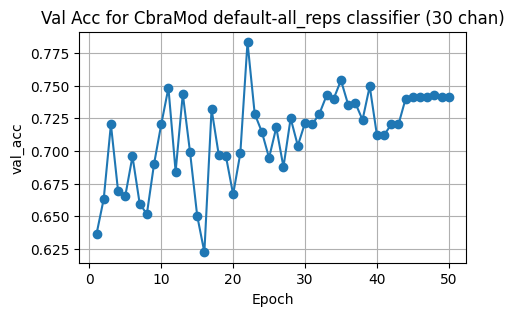

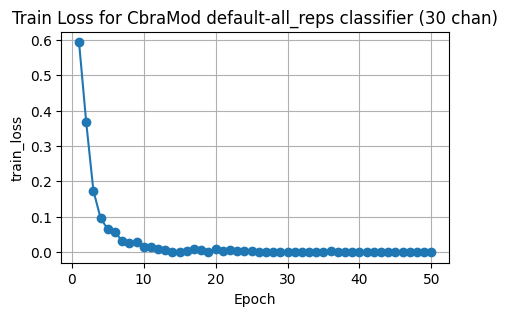

In [19]:
channel_size = 30
classifier_type = 'all_reps'
log_file = f'./models_weights/finetune-Stress_noleak_{channel_size}chan_no400up_seed_siwen42-4review-default-{classifier_type}/training_logs.json'
metrics, epochs = get_metrics(log_file)
plot_metric(epochs, metrics['val_acc'], 'val_acc', f'Val Acc for CbraMod default-{classifier_type} classifier ({channel_size} chan)')
plot_metric(epochs, metrics['train_loss'], 'train_loss', f'Train Loss for CbraMod default-{classifier_type} classifier ({channel_size} chan)')


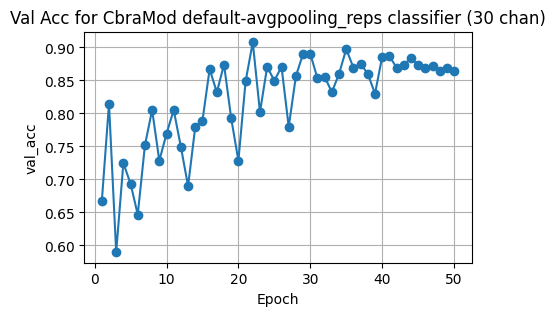

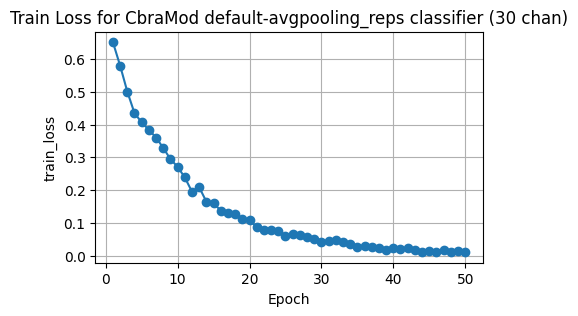

In [18]:
channel_size = 30
classifier_type = 'avgpooling_reps'
log_file = f'./models_weights/finetune-Stress_noleak_{channel_size}chan_no400up_seed_siwen42-4review-default-{classifier_type}/training_logs.json'
metrics, epochs = get_metrics(log_file)
plot_metric(epochs, metrics['val_acc'], 'val_acc', f'Val Acc for CbraMod default-{classifier_type} classifier ({channel_size} chan)')
plot_metric(epochs, metrics['train_loss'], 'train_loss', f'Train Loss for CbraMod default-{classifier_type} classifier ({channel_size} chan)')


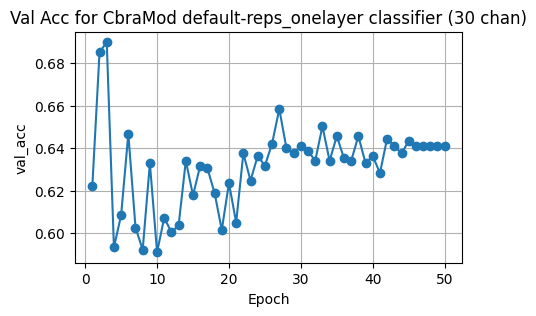

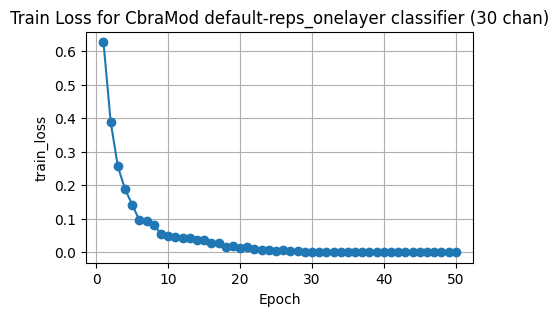

In [20]:
channel_size = 30
classifier_type = 'reps_onelayer'
log_file = f'./models_weights/finetune-Stress_noleak_{channel_size}chan_no400up_seed_siwen42-4review-default-{classifier_type}/training_logs.json'
metrics, epochs = get_metrics(log_file)
plot_metric(epochs, metrics['val_acc'], 'val_acc', f'Val Acc for CbraMod default-{classifier_type} classifier ({channel_size} chan)')
plot_metric(epochs, metrics['train_loss'], 'train_loss', f'Train Loss for CbraMod default-{classifier_type} classifier ({channel_size} chan)')


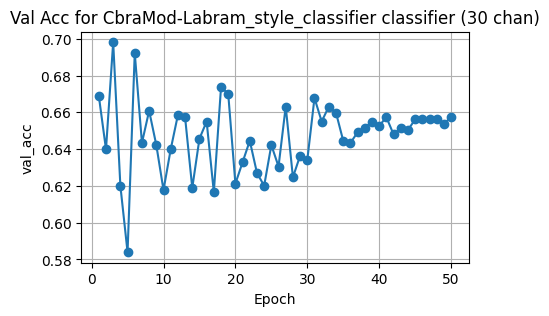

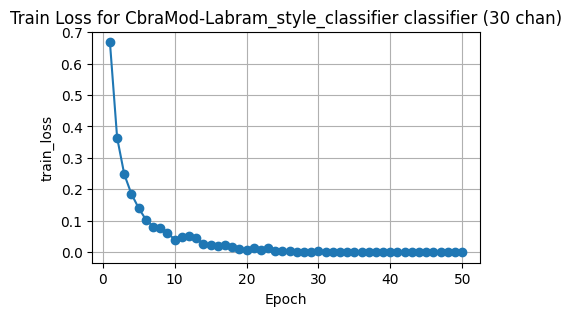

In [ ]:
channel_size = 30
classifier_type = 'Labram_style_classifier'
log_file = f'./models_weights/finetune-Stress_noleak_{channel_size}chan_no400up_seed_siwen42-4review-{classifier_type}/training_logs.json'
metrics, epochs = get_metrics(log_file)
plot_metric(epochs, metrics['val_acc'], 'val_acc', f'Val Acc for CbraMod-{classifier_type} classifier ({channel_size} chan)')
plot_metric(epochs, metrics['train_loss'], 'train_loss', f'Train Loss for CbraMod-{classifier_type} classifier ({channel_size} chan)')


In [20]:
def get_metrics(log_file):
    # Initialize containers for metrics
    epochs = []
    metrics = {
        'train_loss': [], 'val_acc': [], 'val_bacc': [], 'val_pr_auc': [], 'val_roc_auc': [], 'val_cm': [], 
        'test_acc': [], 'test_bacc': [], 'test_pr_auc': [], 'test_roc_auc': [], 'test_cm': [], 
        'learning_rate': [], 'epoch_time_seconds': [], 'epoch_time_minutes': []
    }

    with open(log_file, 'r', encoding='utf-8') as f:
        logs = json.load(f)
        for line in logs:
            epochs.append(line['epoch'])
            for item in metrics:
                metrics[item].append(line[item])
    return metrics, epochs

max val acc: 0.7389277389277389, epoch is 4
test balanced acc in epoch 4: 0.6780697563306259
---
max test balanced acc: 0.752277901127006, epoch is 12


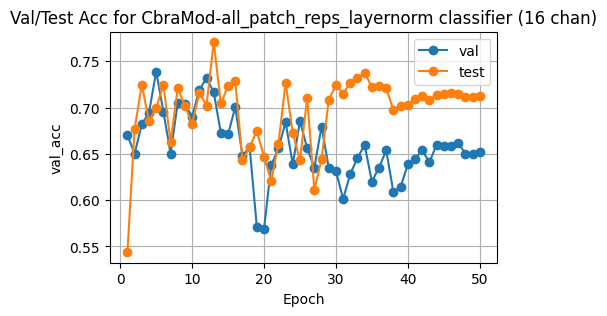

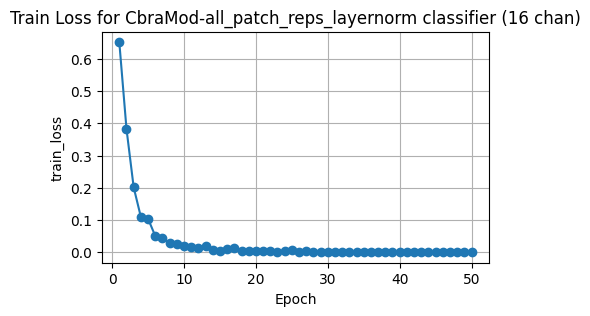

In [24]:
channel_size = 16
classifier_type = 'all_patch_reps_layernorm'
log_file = f'./models_weights/finetune-Stress_noleak_{channel_size}chan_no400up_seed_siwen42-4review-default-{classifier_type}/training_logs.json'
metrics, epochs = get_metrics(log_file)

epoch_id = np.argmax(metrics['val_acc'])
print(f"max val acc: {max(metrics['val_acc'])}, epoch is {epoch_id}")
print(f"test balanced acc in epoch {epoch_id}: {metrics['test_bacc'][epoch_id]}")
print('---')
epoch_id = np.argmax(metrics['test_bacc'])
print(f"max test balanced acc: {max(metrics['test_bacc'])}, epoch is {epoch_id}")

plot_trainNval_metric(epochs, metrics['val_acc'], metrics['test_acc'], 'val_acc', f'Val/Test Acc for CbraMod-{classifier_type} classifier ({channel_size} chan)')
plot_metric(epochs, metrics['train_loss'], 'train_loss', f'Train Loss for CbraMod-{classifier_type} classifier ({channel_size} chan)')